In [87]:
import math
import numpy as np
from matplotlib import pyplot as plt
from pedestrian import *
from solver import Newmarkpseudo_HSI2, Phi_matrix,accdyn_super
from matrix import bridge
from pseudo_excitation import *
from scipy.stats import norm

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80    #kg
peddamp = 0   
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 0 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 2




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])




alpha_COV= np.array([0.05,0.10,0.1,0.1])


alpha_std = mean_alpha*alpha_COV


t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


'''Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = 2 ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

'Human = Pedestrian(\n         mass = randomMass,     #kg\n         damp = peddamp ,   #%\n         stiff = kped, #N/m\n         pace  = 2 ,    #Hz\n         phase = randomPhase,\n         location = pedInlocation,\n         velocity = randomVelocity,\n         \n         iSync=0)'

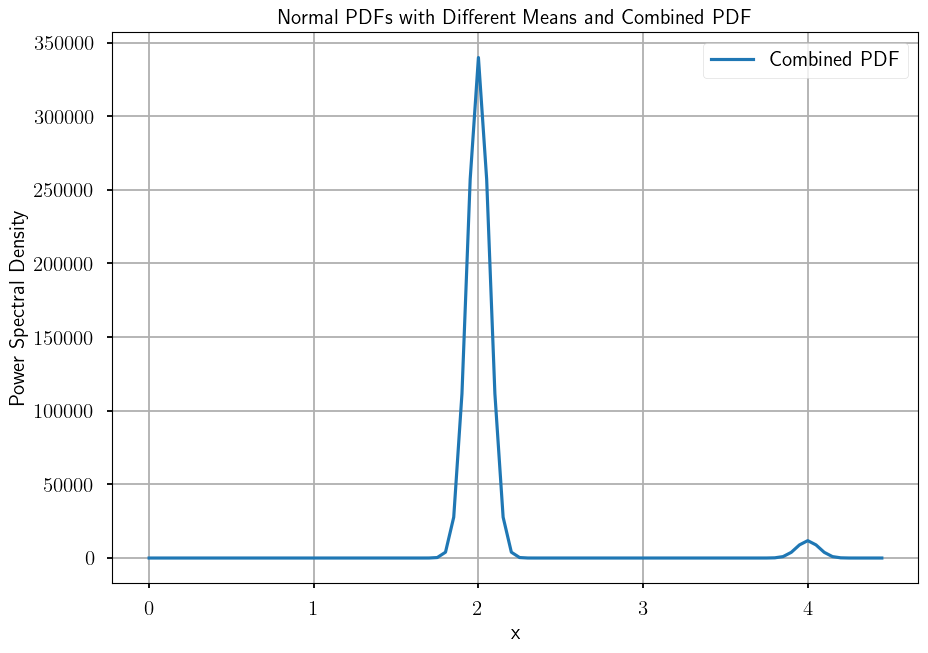

90
0.04999999999999999


In [93]:
from scipy.stats import norm


# Means and standard deviation
means = [2, 4, 6, 8] #the means of harmonics targetted
COV = 0.0335
mean_pace = 2    #maean step frequency
std_dev = mean_pace*COV
mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])
# Generate x values
x = np.arange(0, 10, 0.05)

# Initialize a combined PDF array with zeros
combined_pdf = np.zeros(np.size(x))

# Plot each normal PDF
for i in range (np.size(means)):
    pdf = norm.pdf(x, means[i], std_dev)
    alpha = ((80*9.81*mean_alpha[i])**2)/2
    combined_pdf += pdf*alpha
   


frequencies = np.array(x)
psd = np.array(combined_pdf)
frequencies=frequencies[frequencies<(4.5)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]
# Plot the combined PDF
plt.plot(frequencies, psd, label='Combined PDF')

# Add title and labels
plt.title('Normal PDFs with Different Means and Combined PDF')
plt.xlabel('x')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid(True)
# Show the plot
plt.show()

print(np.size(frequencies))
print(frequencies[4]-frequencies[3])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


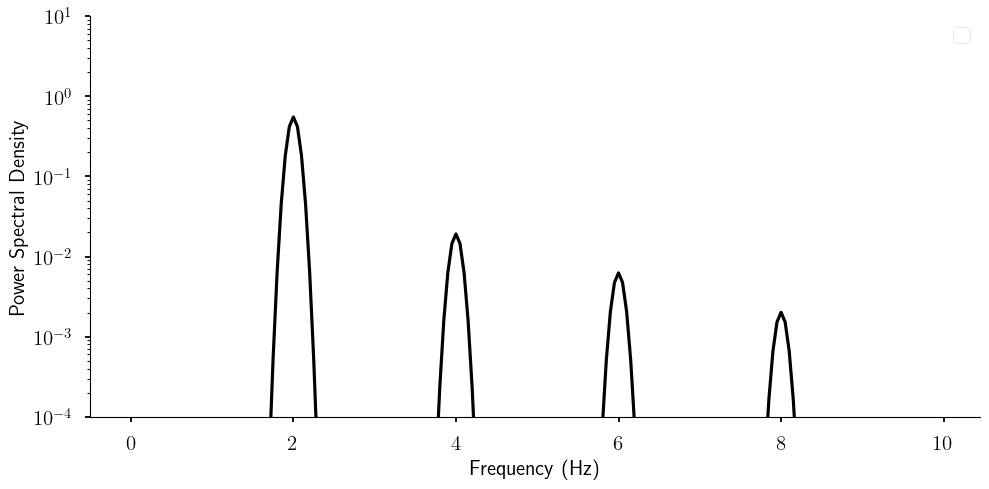

200
0.04999999999999999


In [92]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10#10
plt.rcParams['axes.labelsize'] = 15#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 15#8
plt.rcParams['xtick.labelsize'] = 15#8
plt.rcParams['ytick.labelsize'] = 15#8
plt.rcParams['legend.fontsize'] = 15#10
plt.rcParams['figure.titlesize'] = 15#12
rc('text', usetex=True)

# Plot the combined PDF
plt.figure(figsize=(10,5))
plt.semilogy(frequencies, psd, color='black')

# Add title and labels
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid(false)
# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Limit the y-axis to start from 10^-4
ax.set_ylim(bottom=1e-4)
ax.set_ylim(top=10)

# Adjust layout to prevent cropping
plt.tight_layout()
#plt.savefig("SIMSM_11.pdf", format='pdf', dpi=300)
plt.show()



print(np.size(frequencies))
print(frequencies[4]-frequencies[3])

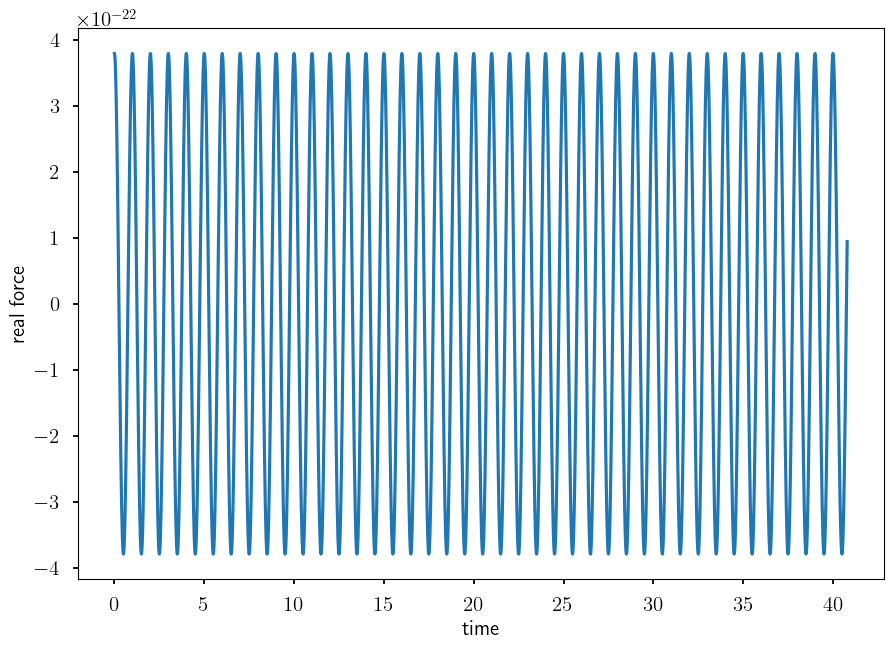

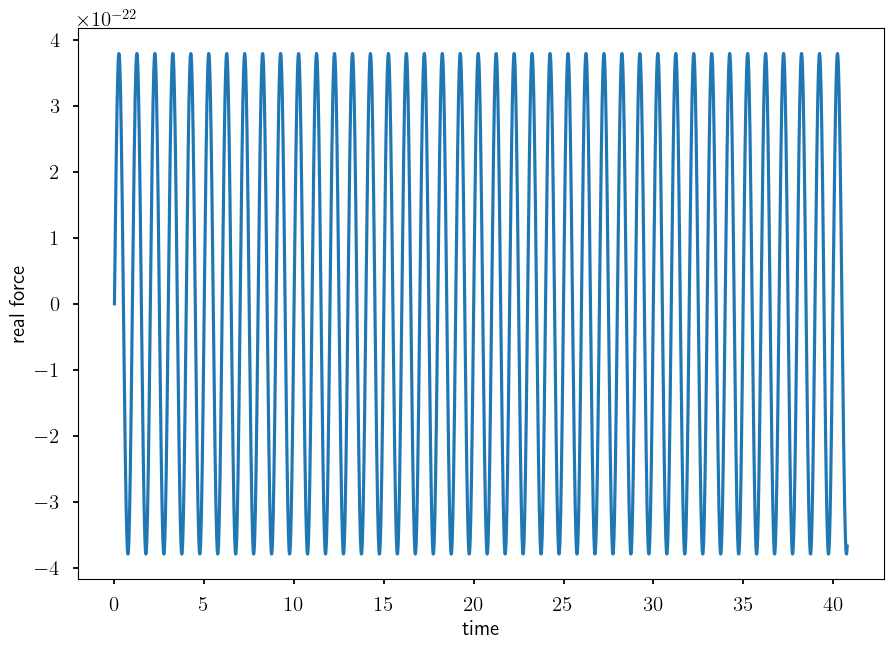

In [80]:
real,imaginary = pseudo_excitation(psd,frequencies,50,1.25,t)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

[[ 0.00000000e+000  7.30988825e-100  1.44957207e-099 ... -1.12674514e-099
  -1.84594720e-099  0.00000000e+000]
 [ 0.00000000e+000  1.37815214e-099  2.42305425e-099 ... -5.30473053e-100
  -1.58766370e-099  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000 ...  0.00000000e+000
   0.00000000e+000  0.00000000e+000]]
[[ 0.00000000e+00  4.37283462e-95  8.67141488e-95 ... -6.74677456e-95
  -1.10573619e-94  0.00000000e+00]
 [ 0.00000000e+00  8.24421824e-95  1.44948263e-94 ... -3.17312121e-95
  -9.49817606e-95  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  1.98007846e-90  3.92647491e-90 ... -3.06387823e-90
  -5.02704107e-90  0.00000000e+00]
 [ 0.00000000e+00  3.73309314e-90  6.56334219e-90 ... -1.43654427e-90
  -4.30177529e-90  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  6.78685818e-86 

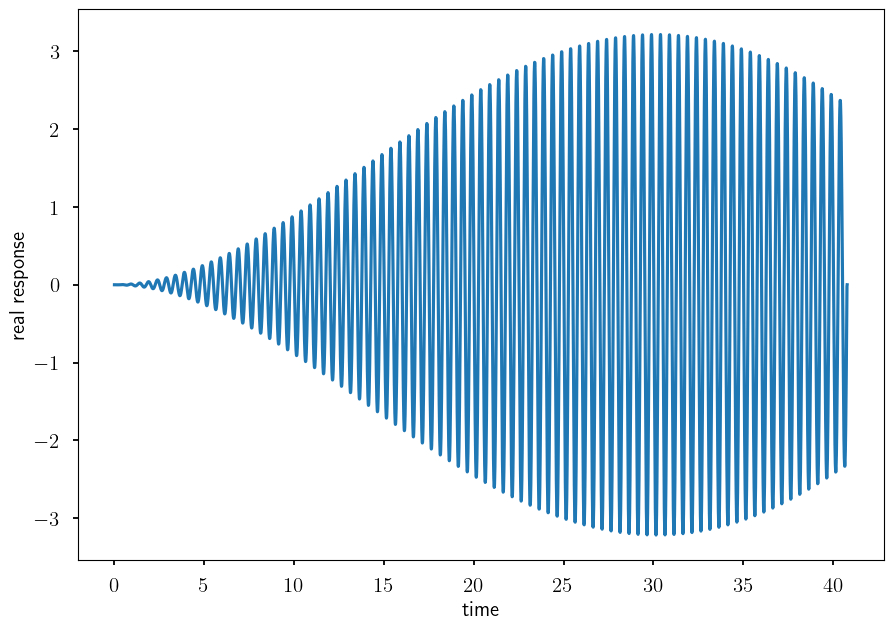

In [81]:
Real_responce = np.zeros((np.size(x),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)


In [82]:
import pickle
with open('Real_responce_NOHSI_SIMSM1_3_35COV.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_NOHSI_SIMSM1_3_35COV.pkl")

Matrix saved to Real_responce_NOHSI_SIMSM1_3_35COV.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.00000000e+00 0.00000000e+00 2.74752766e-97 ... 1.76768507e-95
  1.72529086e-95 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.17998018e-97 ... 1.87951180e-96
  1.68011509e-96 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 2.48822283e-92 ... 1.60692161e-90
  1.56841470e-90 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.69110653e-92 ... 1.70253782e-91
  1.52194178e-91 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 1.27927329e-87 ... 8.31406261e-86
  8.11510531e-86 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.41184480e-87 ... 8.75679230e-87
  7.82813804e-87 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+0

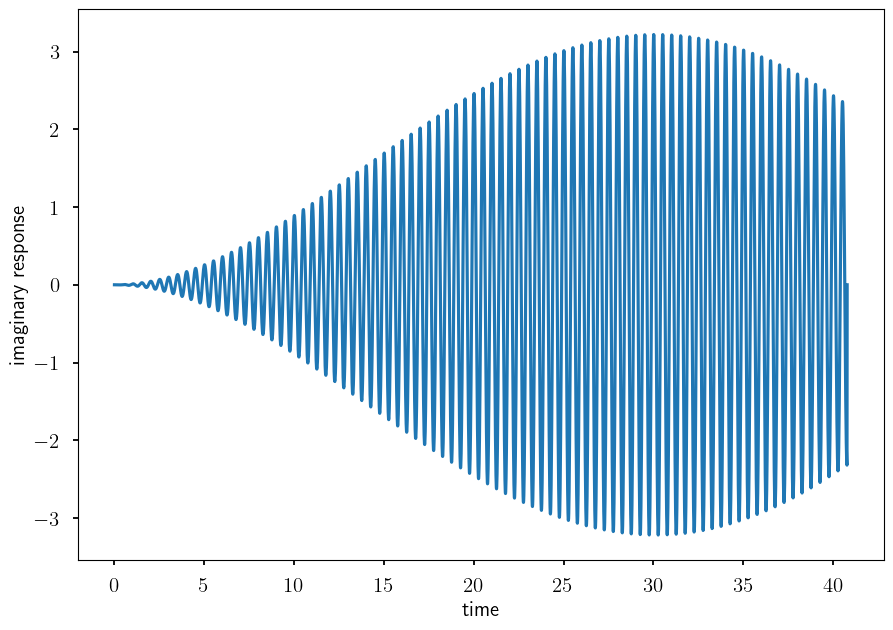

In [83]:
imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)  

In [84]:
import pickle
with open('imag_responce_NOHSI_SIMSM1_3_35COV.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_NOHSI_SIMSM1_3_35COV.pkl")

Matrix saved to imag_responce_NOHSI_SIMSM1_3_35COV.pkl


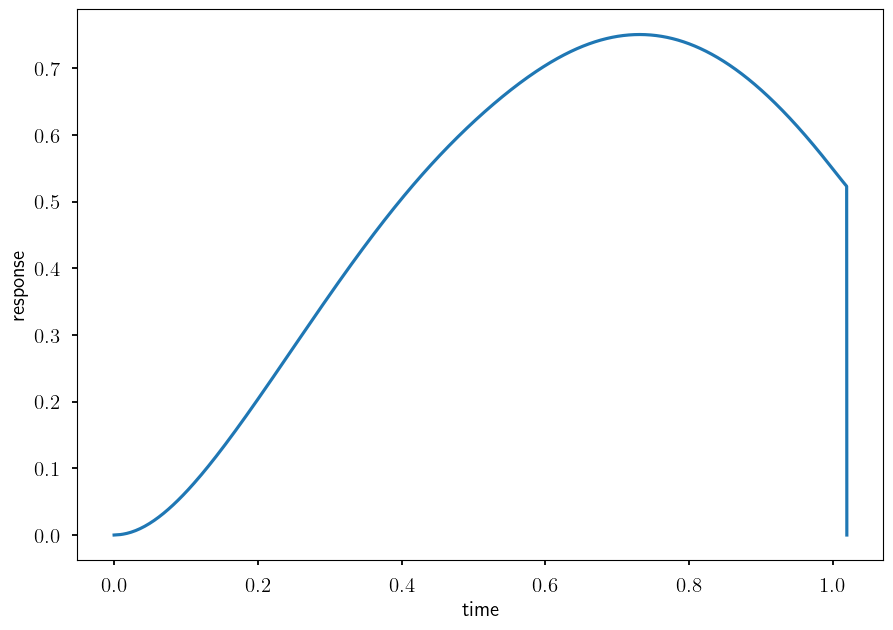

Maximum RMS value: 0.7508410302955931
Corresponding time: 29.26
Matrix saved to SIMSM_3_35COV2_NOHSI.pkl


In [86]:
with open('Real_responce_NOHSI_SIMSM1_3_35COV.pkl', 'rb') as f1:
    Real_responce_SIMSM = pickle.load(f1)
with open('imag_responce_NOHSI_SIMSM1_3_35COV.pkl', 'rb') as f2:
    imag_responce_SIMSM = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce_SIMSM[[j],[i]]**2 + imag_responce_SIMSM[[j],[i]]**2)*delta_f

deterministic_RMS_No_HSI=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),deterministic_RMS_No_HSI.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()

# Find the maximum value and corresponding time
max_value = np.max(deterministic_RMS_No_HSI)
max_index = np.argmax(deterministic_RMS_No_HSI)
max_time = t[max_index]

# Print the maximum value and corresponding time
print(f"Maximum RMS value: {max_value}")
print(f"Corresponding time: {max_time}")


import pickle
with open('SIMSM_3_35COV2_NOHSI.pkl', 'wb') as f:
    pickle.dump(deterministic_RMS_No_HSI, f)

print("Matrix saved to SIMSM_3_35COV2_NOHSI.pkl")

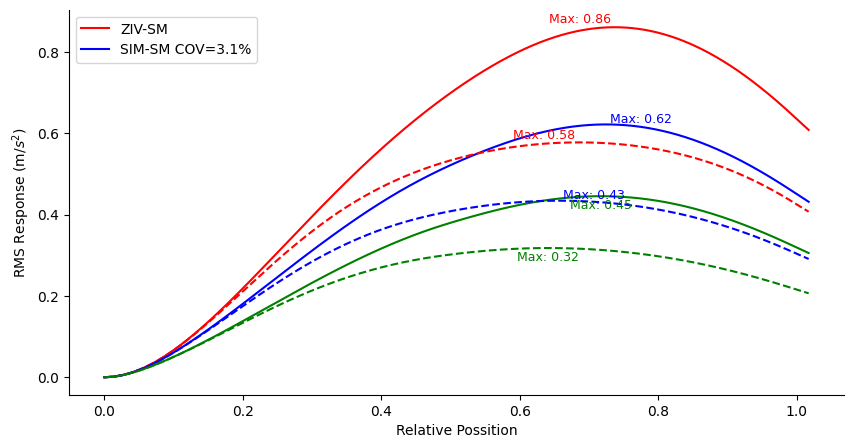

Maximum 0.5-second RMS value: 0.8604 m/s^2 
Maximum 0.5-second RMS value: 0.6215 m/s^2 


In [52]:

with open('SIMSM_25_NOHSI.pkl', 'rb') as f7:
    SIMSM_25_NOHSI = pickle.load(f7)
with open('SIMSM_5_NOHSI.pkl', 'rb') as f8:
    SIMSM_5_NOHSI = pickle.load(f8)
with open('SIMSM_1_NOHSI.pkl', 'rb') as f9:
    SIMSM_1_NOHSI = pickle.load(f9)
with open('SIMSM_25.pkl', 'rb') as f10:
    SIMSM_25 = pickle.load(f10)
with open('SIMSM_5.pkl', 'rb') as f11:
    SIMSM_5 = pickle.load(f11)
with open('SIMSM_1.pkl', 'rb') as f12:
    SIMSM_1 = pickle.load(f12)

# Remove the last 10 points from x
x_trimmed = Xnormal[:-10]
y_flattened  = SIMSM_25_NOHSI.flatten()
y2_flattened  = SIMSM_5_NOHSI.flatten()
y3_flattened  = SIMSM_1_NOHSI.flatten()
y4_flattened  = SIMSM_25.flatten()
y5_flattened  = SIMSM_5.flatten()
y6_flattened  = SIMSM_1.flatten()



# Adjust y to match the length of x_trimmed
y_trimmed = y_flattened [:len(x_trimmed)]
y2_trimmed = y2_flattened [:len(x_trimmed)]
y3_trimmed = y3_flattened [:len(x_trimmed)]
y4_trimmed = y4_flattened [:len(x_trimmed)]
y5_trimmed = y5_flattened [:len(x_trimmed)]
y6_trimmed = y6_flattened [:len(x_trimmed)]




maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
maxvalue3 = np.max(y3_trimmed)
maxvalue4 = np.max(y4_trimmed)
maxvalue5 = np.max(y5_trimmed)
maxvalue6 = np.max(y6_trimmed)


max_x = x_trimmed[np.argmax(y_trimmed)]
max_x2 = x_trimmed[np.argmax(y2_trimmed)]
max_x3 = x_trimmed[np.argmax(y3_trimmed)]
max_x4 = x_trimmed[np.argmax(y4_trimmed)]
max_x5 = x_trimmed[np.argmax(y5_trimmed)]
max_x6 = x_trimmed[np.argmax(y6_trimmed)]


plt.figure(figsize=(10,5))
plt.plot(x_trimmed.flatten(), y_trimmed.T,color='red')
plt.plot(x_trimmed.flatten(), y2_trimmed.T,color='blue')
plt.plot(x_trimmed.flatten(), y3_trimmed.T, color='green')
plt.plot(x_trimmed.flatten(), y4_trimmed.T, color='red',linestyle='--')
plt.plot(x_trimmed.flatten(), y5_trimmed.T, color='blue',linestyle='--')
plt.plot(x_trimmed.flatten(), y6_trimmed.T, color='green',linestyle='--')


plt.annotate(f'Max: {maxvalue1:.2f}', xy=(max_x, maxvalue1), xytext=(max_x-0.05, maxvalue1 + 0.01),
             ha='center',color='red', fontsize=9)
plt.annotate(f'Max: {maxvalue2:.2f}', xy=(max_x2, maxvalue2), xytext=(max_x2+0.05, maxvalue2 + 0.005),
             ha='center',color='blue', fontsize=9)
plt.annotate(f'Max: {maxvalue3:.2f}', xy=(max_x3, maxvalue3), xytext=(max_x3, maxvalue3 - 0.03),
                ha='center',color='green', fontsize=9)
plt.annotate(f'Max: {maxvalue4:.2f}', xy=(max_x4, maxvalue4), xytext=(max_x4-0.05, maxvalue4 + 0.01),
             ha='center',color='red', fontsize=9)
plt.annotate(f'Max: {maxvalue5:.2f}', xy=(max_x5, maxvalue5), xytext=(max_x5+0.05, maxvalue5 + 0.005),
             ha='center',color='blue', fontsize=9)
plt.annotate(f'Max: {maxvalue6:.2f}', xy=(max_x6, maxvalue6), xytext=(max_x6, maxvalue6 - 0.03),
                ha='center',color='green', fontsize=9)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Relative Possition")
plt.ylabel("RMS Response (m/$s^2$)")
plt.legend(["ZIV-SM","SIM-SM COV=3.1%"])
plt.savefig("SIMSM_mached_ZIVSM2", format='pdf', dpi=300)
plt.show()

# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)


print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue2:.4f} m/s^2 ")
